In [26]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis

import matplotlib.pyplot as plt
import xarray as xr

import cartopy.crs as ccrs

In [27]:
is_local_data = False
Month_idx = 4
safe = False
start = None
end = None
max_depth = 3

### Load parameters of the transformations

In [ ]:
mean_keys =["mean_1","mean_2"] 
var_keys = ["var_1","var_2"]

In [ ]:
parameter_sets = {}
for mean_key in mean_keys:
    for var_key in var_keys:
        parameter_sets[f"{mean_key}_{var_key}"] = model.loading.load_params(var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/mean_var_regr_degree/{mean_key}_{var_key}/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")    


the mask should only change if one is based on relative data, and one is abs because the threshold has a diffrent effect

In [30]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["mean_1_var_1"]["detail_mask"].equals(para["detail_mask"]))

chunk_mask = parameter_sets["mean_1_var_1"]["chunk_mask"]


True
True
True
True
True


In [31]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["mean_1_var_1"]["chunk_mask"].equals(para["chunk_mask"]))

detal_mask = parameter_sets["mean_1_var_1"]["detail_mask"]


True
True
True
True
True


In [32]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["mean_1_var_1"]["local_maximas"].equals(para["local_maximas"]))

max = model.mask.mask_mask(parameter_sets["mean_1_var_1"]["local_maximas"],parameter_sets["mean_1_var_1"]["chunk_mask"].mrsol).isel(depth=slice(0, max_depth))
maximas = mesmer.grid.stack_lat_lon(max).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol


True
True
True
True
True


### Load test input

In [33]:
run_idx = 4

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=run_idx)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=run_idx)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### shape inputs

In [34]:
def shape_input(ds, chunk_mask):
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds


In [35]:
input = shape_input(raw_input_for_test, chunk_mask.mrsol)

### Emulate

In [36]:
predictions = {}

In [ ]:
for mean_degree, mean_key in enumerate(mean_keys, start=1):
    for var_degree, var_key in enumerate(var_keys, start=1):
        #mean Prediction
        PolReg_mean = model.stats._parallel_polynomial_regression.ParPolyRegression(degree=mean_degree)
        PolReg_mean = PolReg_mean.from_params(parameter_sets[f"{mean_key}_{var_key}"]["mean"])
        predictions[f"{mean_key}_{var_key}"] = {}
        predictions[f"{mean_key}_{var_key}"]["mean"] = PolReg_mean.predict(input,location_dim="gridcell",regr_dim="time").transpose("gridcell","time", "depth")

        #var Prediction
        PolReg_var = model.stats._parallel_polynomial_regression.ParPolyRegression(degree=var_degree)
        PolReg_var = PolReg_var.from_params(parameter_sets[f"{mean_key}_{var_key}"]["variance"])
        predictions[f"{mean_key}_{var_key}"]["variance"] = PolReg_var.predict(input,location_dim="gridcell", regr_dim="time").transpose("gridcell","time", "depth")

        

### load and shape targets

In [38]:
def shape_target(ds):
    #ds = ds.clip(min = 1e-32)
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth)).drop_vars("depth_bnds")
    return ds

In [39]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds)
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds

In [40]:
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=run_idx)


In [41]:
target_unstacked = shape_target(raw_mrsol_for_test)
target = mask_stack_target(target_unstacked)

#### Scores

In [42]:
score_sets = {}


In [43]:
score_keys = parameter_sets.keys()
score_keys

dict_keys(['mean_1_var_1', 'mean_1_var_2', 'mean_2_var_1', 'mean_2_var_2', 'simple'])

In [44]:
for key in score_keys:
    score_sets[key] = model_analysis.crps_score.crps_norm_score(predictions[key]["mean"],predictions[key]["variance"], target, transformation = "Logit", maximas_da = maximas,ensemble_size = 15)

In [45]:
for s_keys, scores in score_sets.items():
    score_sets[s_keys] = mesmer.grid.unstack_lat_lon_and_align(scores, target_unstacked)
    
    score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],detal_mask.mrsol,"lon", "lat", "depth")
    

In [46]:
all_scores_ds =xr.Dataset({key : score.crps_score for key, score in score_sets.items()})

In [47]:
all_scores_ds.mean(dim=["lon","lat","time"])

<xarray.Dataset> Size: 144B
Dimensions:       (depth: 3)
Coordinates:
  * depth         (depth) float64 24B 0.03 0.19 0.78
Data variables:
    mean_1_var_1  (depth) float64 24B 0.4179 1.642 6.718
    mean_1_var_2  (depth) float64 24B 0.4175 1.646 6.733
    mean_2_var_1  (depth) float64 24B 0.4079 1.635 6.747
    mean_2_var_2  (depth) float64 24B 0.4082 1.637 6.743
    simple        (depth) float64 24B 0.418 1.642 6.722

In [48]:
all_scores_ds.mean(dim=["lon","lat","time"])-all_scores_ds.mean(dim=["lon","lat","time"]).mean_2_var_1

<xarray.Dataset> Size: 144B
Dimensions:       (depth: 3)
Coordinates:
  * depth         (depth) float64 24B 0.03 0.19 0.78
Data variables:
    mean_1_var_1  (depth) float64 24B 0.009971 0.007318 -0.0294
    mean_1_var_2  (depth) float64 24B 0.009575 0.01063 -0.01381
    mean_2_var_1  (depth) float64 24B 0.0 0.0 0.0
    mean_2_var_2  (depth) float64 24B 0.0002336 0.002226 -0.003817
    simple        (depth) float64 24B 0.01004 0.007066 -0.02523

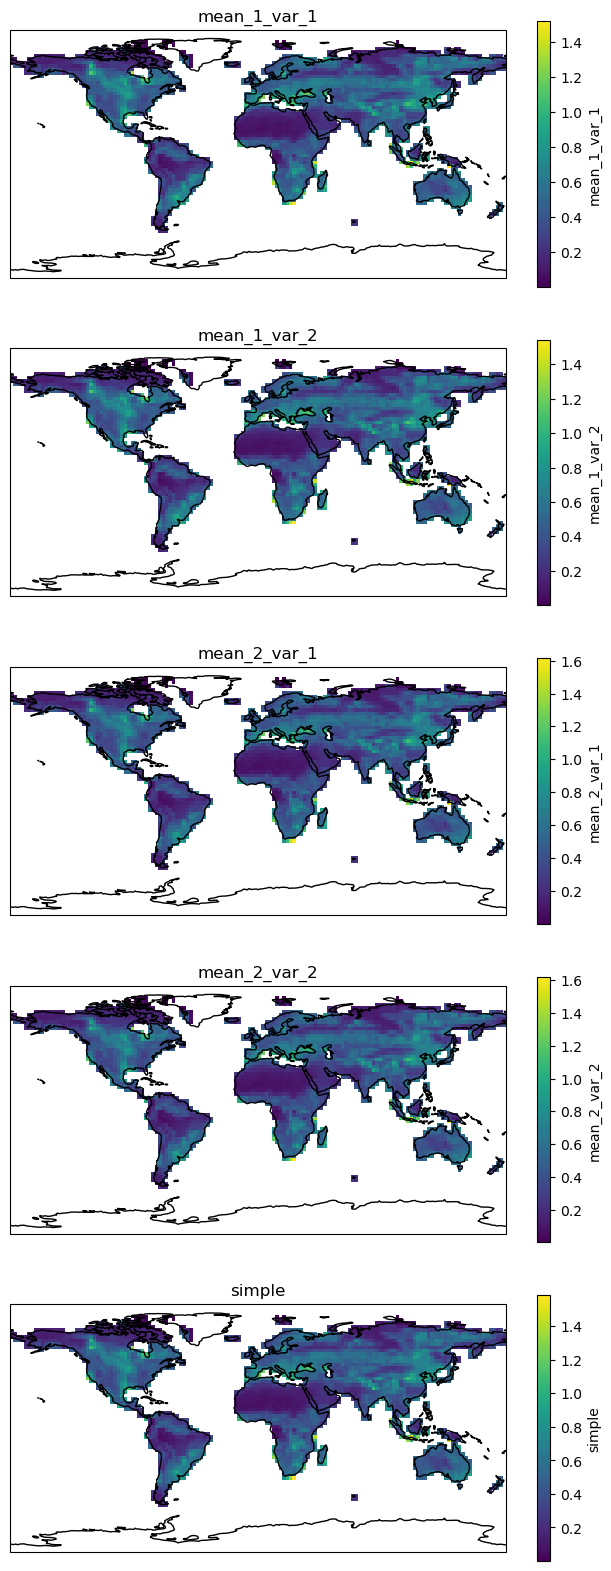

In [49]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=len(score_keys),
    ncols=1,
    figsize=(8, 4 * len(score_keys))
)
depth = 0

for i, s_key in enumerate(score_keys):
    da = all_scores_ds.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[i])
    ax[i].coastlines()
    ax[i].set_title(s_key)



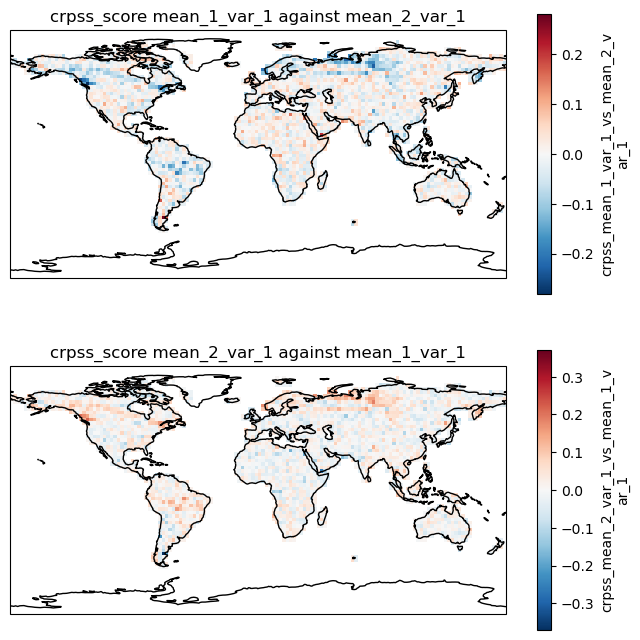

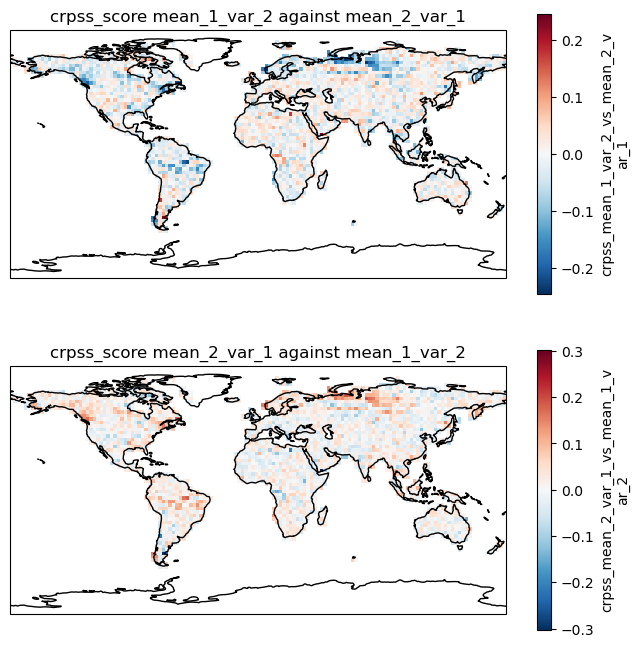

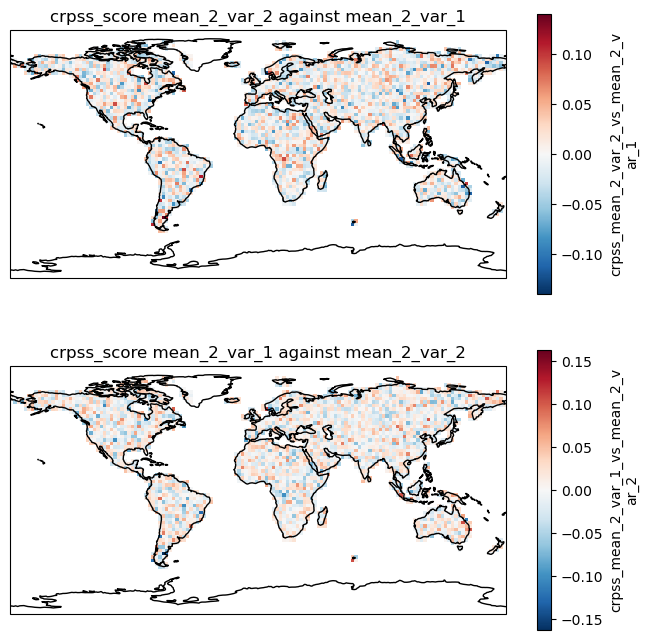

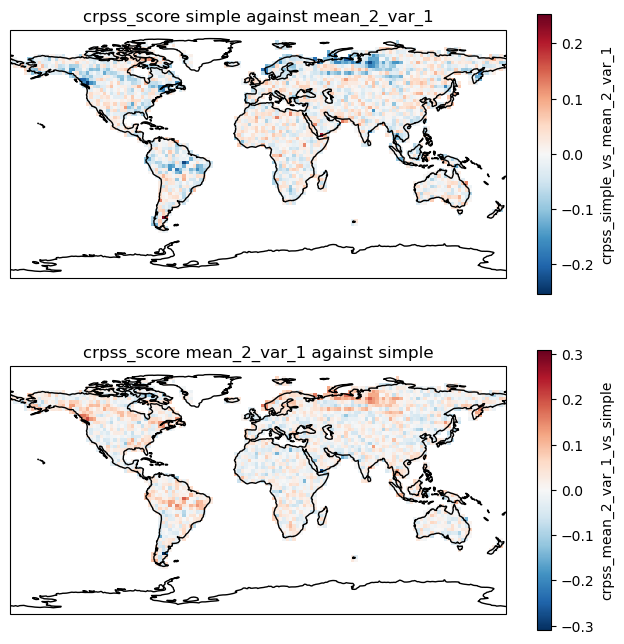

In [50]:
depth = 1

choice = "mean_2_var_1"

for i, s_key in enumerate(score_keys):
    if s_key == choice:
        continue
    vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets[choice].crps_score,score_sets[s_key].crps_score,choice,s_key)

    fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=2,
    ncols=1,
    figsize=(8, 8)
    )
    """
    da = vs.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(s_key)

    da = vs.isel(depth=depth).mean("time")[choice]
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(choice)
    """
    da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_{choice}"].clip(min=-1)
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(f"crpss_score {s_key} against {choice}")

    da = vs.isel(depth=depth)[f"crpss_{choice}_vs_{s_key}"].clip(min=-1)
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(f"crpss_score {choice} against {s_key}")

    fig_global_crpss.show()
    
